<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/Resnet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargar Base

In [3]:
import pandas as pd
ciudades=pd.read_csv('base.csv')

In [ ]:
len(ciudades)

1095

# Resnet18

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

# Cargar ResNet-18 preentrenada
resnet18 = models.resnet18(pretrained=True)
resnet18 = torch.nn.Sequential(*list(resnet18.children())[:-1])  # Quitar la capa final de clasificación
resnet18.eval()  # Poner en modo evaluación

# Transformaciones para las imágenes
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_features(img_path):
    """Extrae features de una imagen usando ResNet-18"""
    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0)  # Añadir batch dimension
    with torch.no_grad():
        features = resnet18(img)
    return features.flatten().numpy()  # Convertir a vector de 512 dimensiones

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]


In [ ]:
import numpy as np

def compute_inequality(image_1km_path, image_10km_path):
    # Extraer características de ambas imágenes
    features_1km = np.mean(extract_features(image_1km_path))
    features_10km = np.mean(extract_features(image_10km_path))

    # Calcular la diferencia entre ambas medidas de desigualdad
    difference = abs(features_1km - features_10km)

    return {
        "Desigualdad cercana (1km)": features_1km,
        "Desigualdad amplia (10km)": features_10km,
        "Diferencia entre ambas": difference
    }

In [ ]:
for i in range(1095):
  if pd.isna(ciudades.loc[i, "Diferencia"]):  # Solo procesar si "Diferencia" está vacío
    try:
        resultados = compute_inequality(ciudades.City[i].replace("/",".").replace(":","_") + " - 1K.png",
                                        ciudades.City[i].replace("/",".").replace(":","_") + " - 10K.png")
        ciudades.loc[i, "Desigualdad_1km"] = resultados["Desigualdad cercana (1km)"]
        ciudades.loc[i, "Desigualdad_10km"] = resultados["Desigualdad amplia (10km)"]
        ciudades.loc[i, "Diferencia"] = resultados["Diferencia entre ambas"]
    except Exception as e:
        print(f"⚠️ Error en compute_inequality: {e}")

⚠️ Error en compute_inequality: [Errno 2] No such file or directory: 'CL_ Coquimbo-La Serena - 1K.png'
⚠️ Error en compute_inequality: [Errno 2] No such file or directory: "CL_ Libertador Bernardo O'Higgins-San Fernando - 1K.png"


# Gráficos y Regresiones

In [11]:
import statsmodels.api as sm

# Definir variables
X = ciudades["Desigualdad_1km"].replace([np.inf, -np.inf], np.nan)
y = ciudades["P1ST"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   P1ST   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     18.63
Date:                Thu, 27 Mar 2025   Prob (F-statistic):           1.73e-05
Time:                        14:41:05   Log-Likelihood:                -478.68
No. Observations:                1093   AIC:                             961.4
Df Residuals:                    1091   BIC:                             971.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.3169      0.049     

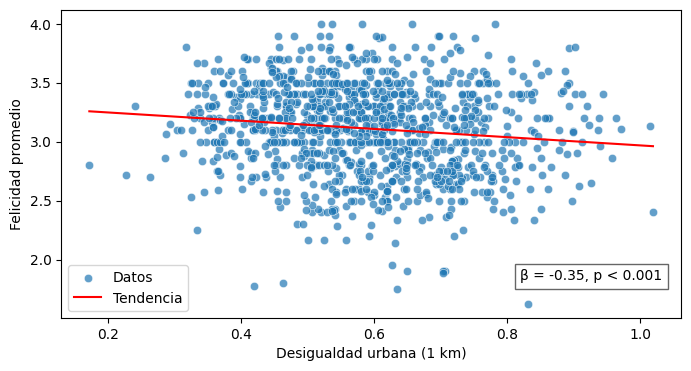

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Definir coeficientes de la regresión
intercept = 3.3169
slope = -0.3489
p_value = "< 0.001"  # Significancia del coeficiente

# Calcular valores ajustados para la línea de tendencia
x_vals = np.linspace(ciudades["Desigualdad_1km"].min(), ciudades["Desigualdad_1km"].max(), 100)
y_vals = intercept + slope * x_vals  # Ecuación de la regresión

# Crear la figura
plt.figure(figsize=(8, 4))

# Graficar los datos (X = desigualdad, Y = felicidad)
sns.scatterplot(data=ciudades, x="Desigualdad_1km", y="P1ST", alpha=0.7, label="Datos")

# Graficar la línea de tendencia correctamente orientada
plt.plot(x_vals, y_vals, color="red", label=f"Tendencia")

# Agregar información sobre la significancia del coeficiente en el gráfico
plt.text(ciudades["Desigualdad_1km"].max()-0.2, ciudades["P1ST"].min()+0.2, f"β = {slope:.2f}, p {p_value}",
         fontsize=10, color="black", bbox=dict(facecolor="white", alpha=0.6))

# Etiquetas y título
plt.xlabel("Desigualdad urbana (1 km)")
plt.ylabel("Felicidad promedio")
#plt.title("Relación entre desigualdad urbana y felicidad")
plt.legend()

# Mostrar el gráfico
plt.show()

In [12]:
# Definir variables
X = ciudades["Desigualdad_10km"].replace([np.inf, -np.inf], np.nan)
y = ciudades["P1ST"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   P1ST   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     34.44
Date:                Thu, 27 Mar 2025   Prob (F-statistic):           5.83e-09
Time:                        14:41:13   Log-Likelihood:                -470.95
No. Observations:                1093   AIC:                             945.9
Df Residuals:                    1091   BIC:                             955.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.3837      0.048  

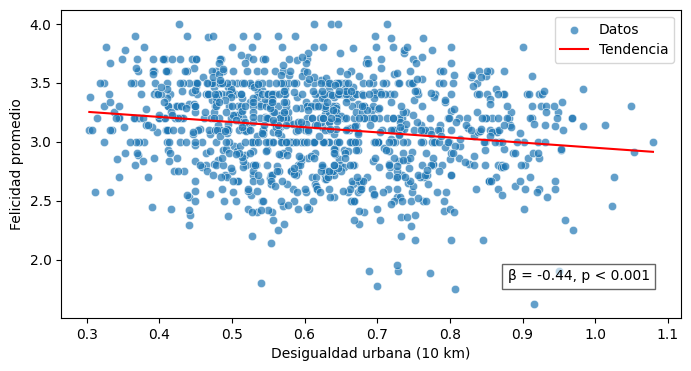

In [8]:
# Definir coeficientes de la regresión
intercept = 3.3837
slope = -0.4356
p_value = "< 0.001"  # Significancia del coeficiente

# Calcular valores ajustados para la línea de tendencia
x_vals = np.linspace(ciudades["Desigualdad_10km"].min(), ciudades["Desigualdad_10km"].max(), 100)
y_vals = intercept + slope * x_vals  # Ecuación de la regresión

# Crear la figura
plt.figure(figsize=(8, 4))

# Graficar los datos (X = desigualdad, Y = felicidad)
sns.scatterplot(data=ciudades, x="Desigualdad_10km", y="P1ST", alpha=0.7, label="Datos")

# Graficar la línea de tendencia correctamente orientada
plt.plot(x_vals, y_vals, color="red", label=f"Tendencia")

# Agregar información sobre la significancia del coeficiente en el gráfico
plt.text(ciudades["Desigualdad_10km"].max()-0.2, ciudades["P1ST"].min()+0.2, f"β = {slope:.2f}, p {p_value}",
         fontsize=10, color="black", bbox=dict(facecolor="white", alpha=0.6))

# Etiquetas y título
plt.xlabel("Desigualdad urbana (10 km)")
plt.ylabel("Felicidad promedio")
#plt.title("Relación entre desigualdad urbana y felicidad")
plt.legend()

# Mostrar el gráfico

plt.show()

# Placebo Test

In [23]:
ciudades["placebo_felicidad"] = np.random.randint(1,5, size=len(ciudades))
ciudades["placebo_desigualdad"] = np.random.uniform(ciudades["Desigualdad_1km"].min(), ciudades["Desigualdad_1km"].max(), size=len(ciudades))

In [25]:
# Definir variables
X = ciudades["placebo_desigualdad"].replace([np.inf, -np.inf], np.nan)
y = ciudades["P1ST"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   P1ST   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.3518
Date:                Thu, 27 Mar 2025   Prob (F-statistic):              0.553
Time:                        14:59:34   Log-Likelihood:                -487.83
No. Observations:                1095   AIC:                             979.7
Df Residuals:                    1093   BIC:                             989.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   3.0949    

# Submuestras

In [31]:
latino=pd.read_stata('/content/Latinobarometro_2023_Esp_Stata_v1_0.dta')

conversion = {
    "No muy satisfecho": 2,
    "Para nada satisfecho": 1,
    "Bastante satisfecho": 3,
    "Muy satisfecho": 4
}

# Reemplazar valores en la columna P1ST
latino["felicidad"] = latino["P1ST"].map(conversion)

In [41]:
latino=latino.groupby("ciudad", as_index=False, observed=True).agg({
    "felicidad": "mean",
    "tamciud": "first"  # Mantiene el primer valor de tamciud por ciudad
})

In [43]:
ciudades=ciudades.merge(latino, left_on="City", right_on="ciudad", how="left")

In [52]:
import numpy as np
import statsmodels.api as sm

# Filtrar las ciudades según el tamaño
ciudades_filtradas = ciudades[ciudades["tamciud"].isin(["(Capital)", "100.001 y más"])]

# Definir variables
X = ciudades_filtradas["Desigualdad_1km"].replace([np.inf, -np.inf], np.nan)
y = ciudades_filtradas["P1ST"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   P1ST   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     3.663
Date:                Thu, 27 Mar 2025   Prob (F-statistic):             0.0592
Time:                        15:37:57   Log-Likelihood:                -32.972
No. Observations:                  81   AIC:                             69.94
Df Residuals:                      79   BIC:                             74.73
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.3537      0.198     

# Bajar la base con el indicador de desigualdad

In [ ]:
from google.colab import files
ciudades.to_csv('base.csv')
files.download('base.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>